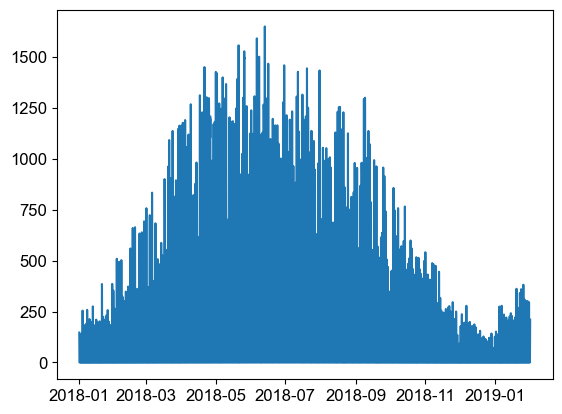

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/2106700032.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)


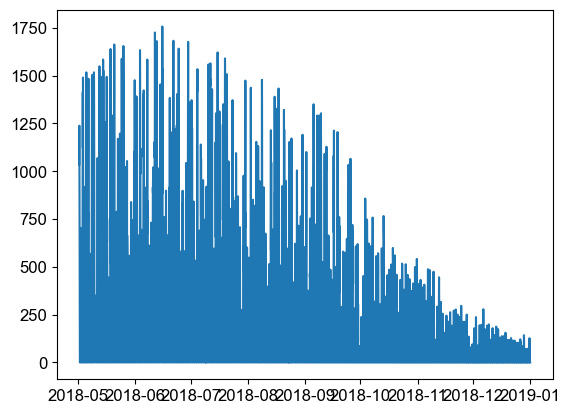

In [464]:
#create FULL light timeseries here
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp

import nbimporter
import NP_timeseries_wCERES

%run NP_timeseries_wCERES.ipynb


In [465]:
start_time = pd.Timestamp('2018-05-01 09:00:00', tz='US/Alaska')
end_time = pd.Timestamp('2018-12-31 23:59:00', tz='US/Alaska')


In [466]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


In [467]:
#load in TS timeseries: convert to AK time and correct indices!
TS_data_2015_2018 = pd.read_csv('/Users/anjalishah/Desktop/Senior_Thesis/Data/fixed_mooring_T_S_2015_2018.csv')
TS_data_2015_2018['time'] = pd.to_datetime(TS_data_2015_2018['time'])
TS_data_2015_2018['time'] = TS_data_2015_2018['time'].dt.tz_localize('UTC', ambiguous='NaT')
TS_data_2015_2018['time']= TS_data_2015_2018['time'].dt.tz_convert('US/Alaska')

TS_data_2018 = TS_data_2015_2018[(TS_data_2015_2018['time'] >= start_time) & (TS_data_2015_2018['time'] <= end_time)] #filter data for correct dates (summer through fall)
TS_data_2018 = TS_data_2018[(TS_data_2018['depth']==15)] #had to use 15 meters since this was the only depth with full timeseries!

TS_data_2018.drop('Unnamed: 0', axis=1, inplace=True)
TS_data_2018.set_index(np.arange(0, len(TS_data_2018)), inplace=True)
TS_data_2018['time'] = TS_data_2018['time'].dt.round('H', ambiguous=True)


/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/2401951794.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  TS_data_2015_2018['time'] = pd.to_datetime(TS_data_2015_2018['time'])
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/2401951794.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  TS_data_2018['time'] = TS_data_2018['time'].dt.round('H', ambiguous=True)


In [468]:
#full chlorophyll timeseries 
#convert to AK time 
chl_data_2018 = pd.read_csv('/Users/anjalishah/Desktop/Senior_Thesis/Data/18bsm2_0011m_chl_2018.csv', header=2)
chl_data_2018['time'] = pd.to_datetime(chl_data_2018['time'], format='%m/%d/%y %H:%M')
chl_data_2018['time'] = chl_data_2018['time'].dt.tz_localize('UTC')
chl_data_2018 = chl_data_2018.dropna(subset=['time'])
chl_data_2018['time'] = chl_data_2018['time'].dt.tz_convert('US/Alaska')
chl_data_2018 = chl_data_2018[(chl_data_2018['time'] >= start_time) & (chl_data_2018['time'] <= end_time)]
chl_data_2018.set_index(np.arange(0, len(chl_data_2018)), inplace=True)
chl_data_2018['time'] = chl_data_2018['time'].dt.round('H', ambiguous=True)



/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/3847014378.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chl_data_2018['time'] = chl_data_2018['time'].dt.round('H', ambiguous=True)


In [469]:
light_data_2018 = light_data_2018.dropna(subset=['time'])
light_data_2018.set_index(np.arange(0, len(light_data_2018)), inplace=True)
light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/1332439080.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)


In [470]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


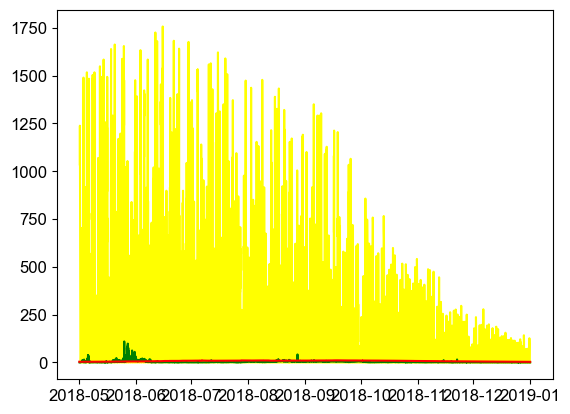

In [158]:
#ensure the timeseries look normal 
plt.plot(light_data_2018['time'], light_data_2018['approxPAR'], color='yellow')
plt.plot(chl_data_2018['time'], chl_data_2018[' ugrams/l'], color='green')
plt.plot(TS_data_2018['time'], TS_data_2018['temperature'], color='red')

In [159]:
TS_data_2018


,time,depth,temperature,salinity,season
0,2018-05-01 09:00:00-08:00,15,3.6514,NaN,summer
1,2018-05-01 10:00:00-08:00,15,3.4909,NaN,summer
2,2018-05-01 11:00:00-08:00,15,3.4623,NaN,summer
3,2018-05-01 12:00:00-08:00,15,3.2874,NaN,summer
4,2018-05-01 13:00:00-08:00,15,3.3350,NaN,summer
...,...,...,...,...,...
5872,2018-12-31 20:00:00-09:00,15,3.2960,NaN,winter
5873,2018-12-31 21:00:00-09:00,15,3.3240,NaN,winter
5874,2018-12-31 22:00:00-09:00,15,3.3320,NaN,winter
5875,2018-12-31 23:00:00-09:00,15,3.3380,NaN,winter


In [160]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 20:00:00-09:00,0.0000
5855,2018-12-31 20:00:00-09:00,0.0000
5856,2018-12-31 22:00:00-09:00,0.0000
5857,2018-12-31 22:00:00-09:00,0.0000


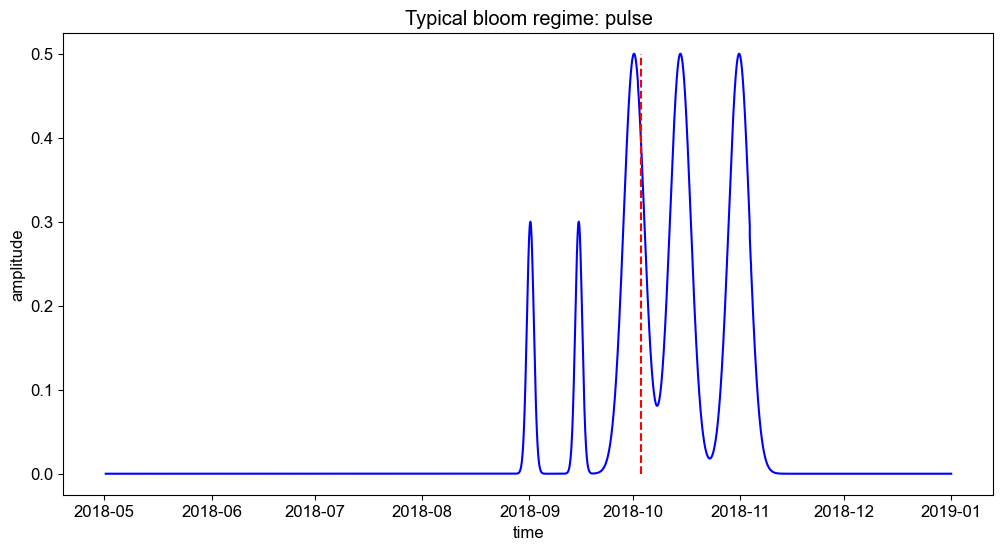

In [521]:
#pulse set up 
def gaussian(t, center, amp, width): 
    return amp * np.exp(-(t-center)**2 / (2*width**2))

#select forcing 

#forcing 1: 3 small storms 
# gaussian(TS_data_2018.index, 2949, 0.3, 24) + gaussian(TS_data_2018.index, 3669, 0.3, 24) + gaussian(TS_data_2018.index, 4400, 0.3, 24) 

#forcing 2: abundant storms: 
# gaussian(TS_data_2018.index, 2949, 0.3, 24) + gaussian(TS_data_2018.index, 3669, 0.3, 24) + gaussian(TS_data_2018.index, 3992, 0.5, 72) + gaussian(TS_data_2018.index, 4400, 0.5, 72) + gaussian(TS_data_2018.index, 4747, 0.5, 72)

Forcing_plotted = gaussian(TS_data_2018.index, 2949, 0.3, 24) + gaussian(TS_data_2018.index, 3285, 0.3, 24) + gaussian(TS_data_2018.index, 3669, 0.5, 72) + gaussian(TS_data_2018.index, 3992, 0.5, 72) + gaussian(TS_data_2018.index, 4400, 0.5, 72) 
plt.figure(figsize=(12,6))
plt.plot(TS_data_2018.time, Forcing_plotted, color='blue')
plt.vlines(x=timestamp[first_occurrence], ymin=0, ymax=0.5, colors='r', linestyles='--')
plt.title('Typical bloom regime: pulse')
plt.ylabel('amplitude')
plt.xlabel('time')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/pulse_structure.jpg', dpi=300, bbox_inches='tight')




Text(0.5, 1.0, 'Cumulative Light Limitation (in response to pulses)')

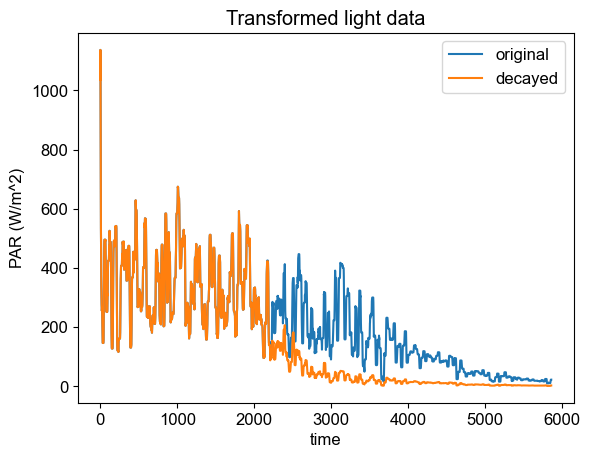

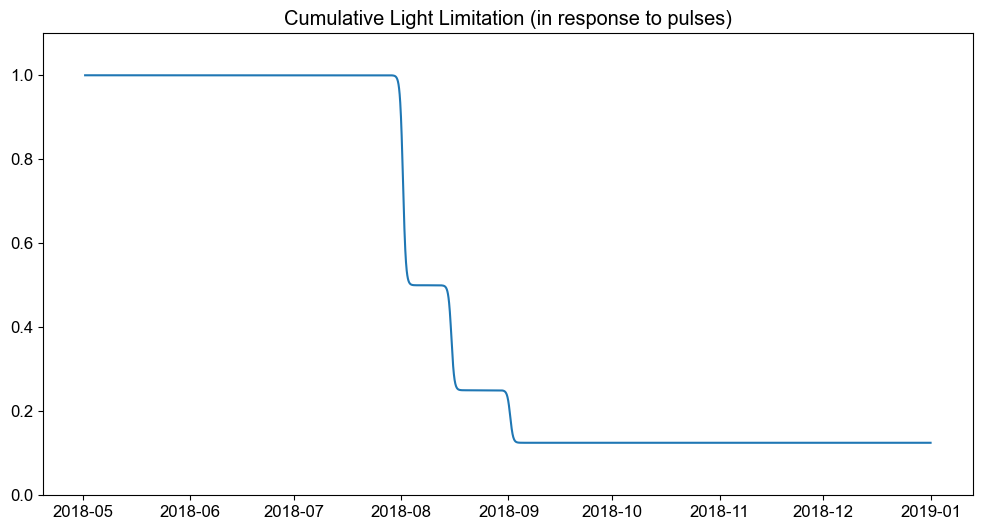

In [651]:
strat_index = 0.2
#step function set up: relates LIGHT to nutrient pulses through implicit transformation of Mixed Layer Depth! 

light_data_2018 #original data
# function goes between 0 and 0.5 (each pulse halves the light levels) --> just a guess, would depend on empirical relationship --> also should depend on amplitude of gaussian!!
#steepness represents slope between 1 and 0.5 --> would depend on empirical relationship
# hours = index of M2 timeseries
# threshold_hours = time of given pulse 

def create_tanh_decay(threshold_hours, hours, original_data, steepness=0.05): #change strat_index here --> so that storms disturb MLD more even if they are small in magnitude 
    """
    Creates a decay function that:
    - Returns 1 before threshold_hours
    - Smoothly transitions from 1 to 0.5 after threshold_hours using tanh
    
    Args:
        threshold_hours (float): Hours after which decay begins
        steepness (float): Controls how quickly the transition happens
    
    Returns:
        function: A function that takes hours as input and returns the decay factor
    """# Shift and scale tanh to get desired range [1.0, 0.5], # tanh goes from -1 to 1, so we scale and shift to go from 1 to 0.5
    #what we want: low strat = low number (close to zero), high strat = high number (close to 1). 
    # low strat = bigger storm disturbances with less wind, high strat = smaller storm disturbances with more wind!! --> strat held constant during pulsing experiments! 
    if 0 < strat_index < 0.25:
        if threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 50% (small storms)
            decay_function = 0.75 - 0.25 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 70% (large storms)
            decay_function =0.65 - 0.35 * np.tanh(steepness * (hours - threshold_hours)) 
    elif 0.25 < strat_index < 0.5: 
        if threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 40% (small storms)
            decay_function = 0.8 - 0.2 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 60% (large storms)
            decay_function = 0.7 - 0.3 * np.tanh(steepness * (hours - threshold_hours))
    elif 0.5 <= strat_index < 0.75: #avg strat conditions = 0.5 
        if threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 30% (small storms)
            decay_function = 0.85 - 0.15 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 50% (large storms)
            decay_function = 0.75 - 0.25 * np.tanh(steepness * (hours - threshold_hours))
    else: #stratification conditions!!
        if threshold_hours <= 3992:  # if threshold is before October 15th, reduce light by 20% (small storms)
            decay_function = 0.95 - 0.05 * np.tanh(steepness * (hours - threshold_hours))
        else: #if threshold is after this, reduce light by 40% (large storms)
            decay_function = 0.8 - 0.2 * np.tanh(steepness * (hours - threshold_hours)) #notice that this is the same condition as small storms with super low stratification!
    decayed_data = original_data * decay_function
    return decayed_data, decay_function


#modified light function
# code for abundant pulses --> start at 2949??
#decayed_data_one, decay_function_one = create_tanh_decay(2949, light_data_2018.index, light_data_2018['approxPAR'])
#decayed_data_two, decay_function_two = create_tanh_decay(3285, decayed_data_one.index, decayed_data_one)
#decayed_data_three, decay_function_three = create_tanh_decay(3669, decayed_data_two.index, decayed_data_two)
#decayed_data_four, decay_function_four = create_tanh_decay(3992, decayed_data_three.index, decayed_data_three)
#decayed_data_five, decay_function_five = create_tanh_decay(4400, decayed_data_four.index, decayed_data_four)

#early fall bloom pulses
decayed_data_one, decay_function_one = create_tanh_decay(2205, light_data_2018.index, light_data_2018['approxPAR'])
decayed_data_two, decay_function_two = create_tanh_decay(2541, decayed_data_one.index, decayed_data_one)
decayed_data_three, decay_function_three = create_tanh_decay(2949, decayed_data_two.index, decayed_data_two)

# plt.figure()
# plt.plot(light_data_2018['approxPAR'].rolling(24, min_periods=1).mean())
# plt.plot(decayed_data_five.rolling(24, min_periods=1).mean())
# plt.legend(['original','decayed'])
# plt.title('Transformed light data')
# plt.xlabel('time')
# plt.ylabel('PAR (W/m^2)')

# plt.figure(figsize=(12, 6))
# plt.plot(light_data_2018['time'], decay_function_one*decay_function_two*decay_function_three*decay_function_four*decay_function_five)
# plt.title('Cumulative Light Limitation (in response to pulses)')


#code for sparse  pulses --> need to modify tanh function here!

#decayed_data_one, decay_function_one = create_tanh_decay(2949, light_data_2018.index, light_data_2018['approxPAR'])
#decayed_data_two, decay_function_two = create_tanh_decay(3669, decayed_data_one.index, decayed_data_one)
#decayed_data_three, decay_function_three = create_tanh_decay(4400, decayed_data_two.index, decayed_data_two)

plt.figure()
plt.plot(light_data_2018['approxPAR'].rolling(24, min_periods=1).mean())
plt.plot(decayed_data_three.rolling(24, min_periods=1).mean())
plt.legend(['original','decayed'])
plt.title('Transformed light data')
plt.xlabel('time')
plt.ylabel('PAR (W/m^2)')

plt.figure(figsize=(12, 6))
plt.plot(light_data_2018['time'], decay_function_one*decay_function_two*decay_function_three)
plt.ylim([0,1.1])
plt.title('Cumulative Light Limitation (in response to pulses)')



In [641]:
strat_index

0.2

In [622]:
light_data_mod_pulses = pd.DataFrame({
        'time': light_data_2018.time,
        'approxPAR': decayed_data_five
    })

In [623]:
print(light_data_mod_pulses['time'].dtype)
print(chl_data_2018['time'].dtype)
print(TS_data_2018['time'].dtype)

print(light_data_mod_pulses['time'].dt.tz)
print(chl_data_2018['time'].dt.tz)
print(TS_data_2018['time'].dt.tz)

print(light_data_mod_pulses['time'].min(), light_data_mod_pulses['time'].max())
print(chl_data_2018['time'].min(), chl_data_2018['time'].max())
print(TS_data_2018['time'].min(), TS_data_2018['time'].max())

datetime64[ns, US/Alaska]
datetime64[ns, US/Alaska]
datetime64[ns, US/Alaska]
US/Alaska
US/Alaska
US/Alaska
2018-05-01 15:00:00-08:00 2018-12-31 23:00:00-09:00
2018-05-01 13:00:00-08:00 2018-12-31 23:00:00-09:00
2018-05-01 09:00:00-08:00 2019-01-01 00:00:00-09:00


In [624]:
M2_2018_all = pd.merge(light_data_mod_pulses, chl_data_2018, on='time', how='inner') #add in pulsed light, right now we have original light since there are no pulses
M2_2018_all = pd.merge(M2_2018_all, TS_data_2018, on='time', how='inner')
I=(pd.DataFrame((M2_2018_all['approxPAR'].fillna(method='bfill')))) #backfill NaNs
I = I.mul(0.5) #scale by 0.5 because we have surface irradiance values

T = pd.DataFrame(M2_2018_all['temperature'].fillna(method='bfill')) #define temp function as temp data from M2

#interpolate
time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
I_interp = scipy.interpolate.interp1d(time_eval, I['approxPAR'], kind='linear', fill_value = 'extrapolate')
T_interp = scipy.interpolate.interp1d(time_eval, T['temperature'], kind='linear', fill_value = 'extrapolate')


#plt.plot(M2_2018_all['time'], M2_2018_all['approxPAR'])
#plt.plot(M2_2018_all['time'], M2_2018_all[' ugrams/l'])
#plt.plot(M2_2018_all['time'], M2_2018_all['temperature'])


/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/2267331362.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I=(pd.DataFrame((M2_2018_all['approxPAR'].fillna(method='bfill')))) #backfill NaNs
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/2267331362.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  T = pd.DataFrame(M2_2018_all['temperature'].fillna(method='bfill')) #define temp function as temp data from M2


In [625]:
mu = .06 #phyto max growth rate / hr-1 --> Jin et. al 
r = .0633 #temp coefficient deg-1 -->  Jin et. al 
r_g = .03 #temp coefficient deg-1 -->  Jin et. al 
R_g_0 = 9.23e-4 #max mortality rate at 0 degrees (h-1) -->  Jin et. al 
Vmax = 1e-5 #max nitrogen uptake rate (NO3 and NH4) -->  fNO3 in Jin et. al, defined as Vmax in Eslinger et. al ?? confused here... 
fNO3 = .01 #from Jin et. al, maybe this is wrong, unsure????
alpha = .05 # light --> photosynthesis conversion rate, mgC / [mg Chla h W m2] --> Eslinger et. al 
beta = 0 #photoinhibition coefficient mg C /(mg Chla h W m2) --> Eslinger et. al 
P_B_S = 3.25 #max photosynthesis rate, mcg C/(mgChlhr) --> Eslinger et. al 
k_s = 1.0 #MM half staturation constant, change to get small versus large cells!!!
#gamma_D = .006 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#gamma_F = .087 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#photo_slope = .055 #initial photosynthetic slope -->  Jin et. al 

In [629]:
#photosynthetic rate with irradiance -> create dimensionless value to compare with V_Frac

def P_B(I): 
    P_B = P_B_S*(1-(np.exp(-(alpha*I)/P_B_S)))*(np.exp((-beta*I)/P_B_S)) 
    P_frac = P_B/P_B_S
    return P_frac

def N_in(t):
    return 0.0208 # hr^-1 value from EPOC 2023 poster Pellend et. al --> entrainment approximation

def V_frac(N): #create dimensionless nitrogen value to compare with V_frac
    V_N = Vmax * (N/(N+k_s))
    if V_N < 0: 
        print(N)
    return V_N / Vmax 

In [630]:
#define rates function: here flagellate growth rates and diatom growth rates do not differ
def phyto_rates(T, N_frac, I_frac): 
    phyto_growth = mu * np.exp(r*T) * min(N_frac, I_frac) #growth, use minimum of dimensionless nitrogen and irradiance
    phyto_resp = .05 * mu * np.exp(r*T) #respiration
    phyto_mortality = R_g_0 * np.exp(r_g * T) #mortality
    return [phyto_growth, phyto_resp, phyto_mortality]

Index([2205], dtype='int64')
Index([2541], dtype='int64')
Index([2949], dtype='int64')
Index([3992, 3993], dtype='int64')
Index([4400, 4401], dtype='int64')
Index([4747], dtype='int64')
Index([5131], dtype='int64')
Index([5467], dtype='int64')
Index([5707], dtype='int64')


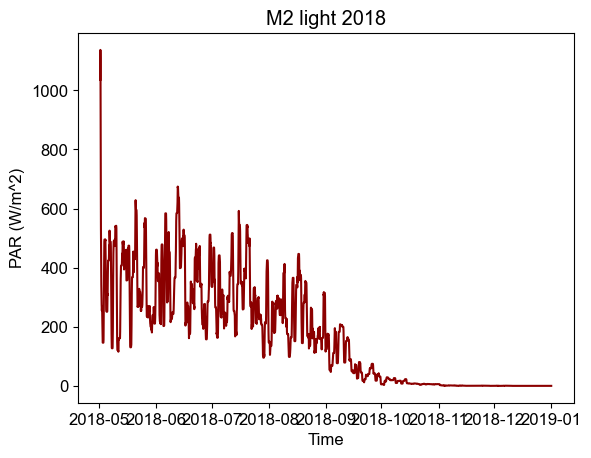

In [648]:
timestamp = M2_2018_all['time']
plt.plot(M2_2018_all.time, M2_2018_all['approxPAR'].rolling(24, min_periods=1).mean(), color='darkred')
plt.title('M2 light 2018')
plt.xlabel('Time')
plt.ylabel('PAR (W/m^2)')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/M2_light_2018.jpg', dpi=300, bbox_inches='tight')

#selection of pulse points: 
print(M2_2018_all[M2_2018_all['time'] == '2018-08-01 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-08-15 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-09-01 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-10-15 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-11-01 12:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-11-15 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-01 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-15 13:00:000'].index)
print(M2_2018_all[M2_2018_all['time'] == '2018-12-25 13:00:000'].index)

In [632]:
#define growth rate function: relates phytoplankton growth rate to temperature 
#define npz system
I_frac = [None] * len(time_eval)
N_frac = [None] * len(time_eval)
dP_stored = [None] * len(time_eval)
def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
    [N, P] = X
    Temp = T_interp(t)
    I_value = I_interp(t)
    PBI = P_B(I_value) #calculate dimensionaless irradiance: I_frac
    V_frac_calc = V_frac(N) #calculate dimensionaless nutrients: N_frac
    if V_frac_calc < 0: 
        V_frac_calc = 0 
    if I_frac[round(t)] == None: #takes the first value, not the last! 
        I_frac[round(t)] = (P_B(I_value)) #store I_frac
        N_frac[round(t)] = (V_frac_calc) #store N_frac
    [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
    strat_index = 0.2 # if strat_index < 1, stratification is lower than normal (0.5, density differences lower than usual) --> pulses get multiplied by 1/sqrt(fraction) to account for a LARGER nutrient disturbance with the same amount of wind  
    F = (1/np.sqrt(strat_index)) * (gaussian (t, 2949, 0.3, 24) + gaussian(t, 3285, 0.3, 24) +  gaussian(t, 3669, 0.3, 24) + gaussian(t, 3992, 0.3, 24) + gaussian(t, 4400, 0.5, 72))
    dN_dt = - (P*(phyto_growth-phyto_resp)) + N_in(t) + F
    #dN_dt = N + #create new function here!
    dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
    if dP_stored[round(t)] == None:
        dP_stored[round(t)] = dP_dt #store dP_dt value 
    #print(PBI)
    #print(V_frac_calc)
    #print(phyto_mortality)
    #rho_t[round(t)] = I_value
    return [dN_dt, dP_dt]


In [633]:
#initial condtions 
N0 = 0.5
P0 = 0.5
init = [N0, P0]

#time range
time_eval = np.linspace(0, len(M2_2018_all)-1, len(M2_2018_all)) #create values to interpolate along
time = (0, len(M2_2018_all)-1)


In [634]:
M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

-0.05176731847832461
-0.07782647060884934
-0.07701422767687136
-0.11015239441509908
-0.09170040001668511
-0.09916231779773277
-0.1521075714692769
-0.010698460328770754
-0.010667562858254598
-0.10265504169831641
-0.22397767256233347
-0.032423106246873334
-0.19495953784910852
-0.18230529300345966
-0.08403310264368408
-0.10504622225132276
-0.19982186571375543
-0.3442990347753757
-0.26781927731524535
-0.24567105102071451
-0.08996422278771127
-0.2504943378899752
-0.18857109126949517
-0.3708817820892654
-0.5229478254562678
-0.15392038681776887
-0.15399445774361287
-0.0915105646184603
-0.1869660237498793
-0.18700923383197415
-0.09203084000959408
-0.19774538687804116
-0.19781354827048286
-0.07497750785311513
-0.093324686843832
-0.43367578022822384
-0.0933720745762926
-0.433789654461745
-0.07560284941704251
-0.07311310556839465
-0.0938762210938448
-0.10659647740944245
-0.10654860163085889
-0.07800916342625869
-0.30218563661968345
-0.44299056010002036
-0.30216315485091305
-0.4429393307341535
-0.

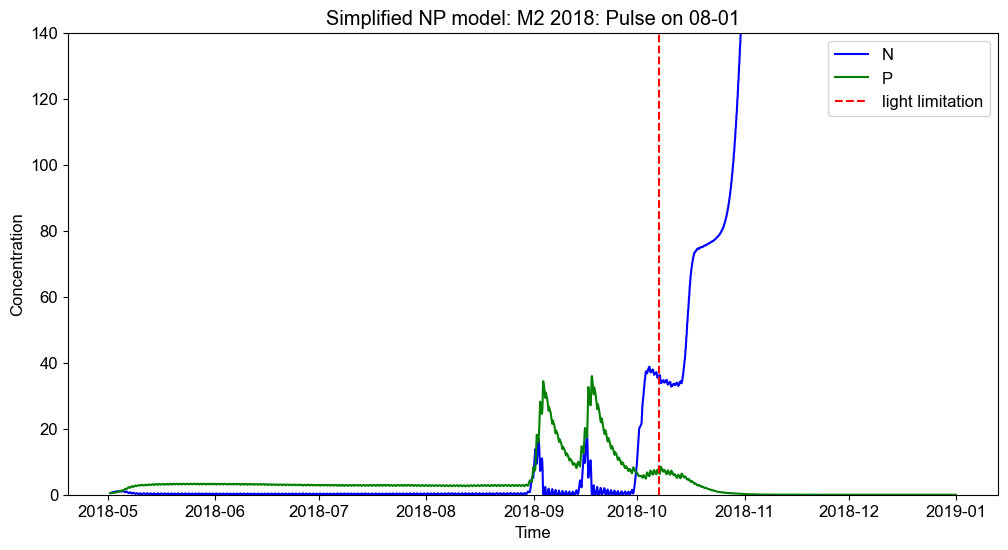

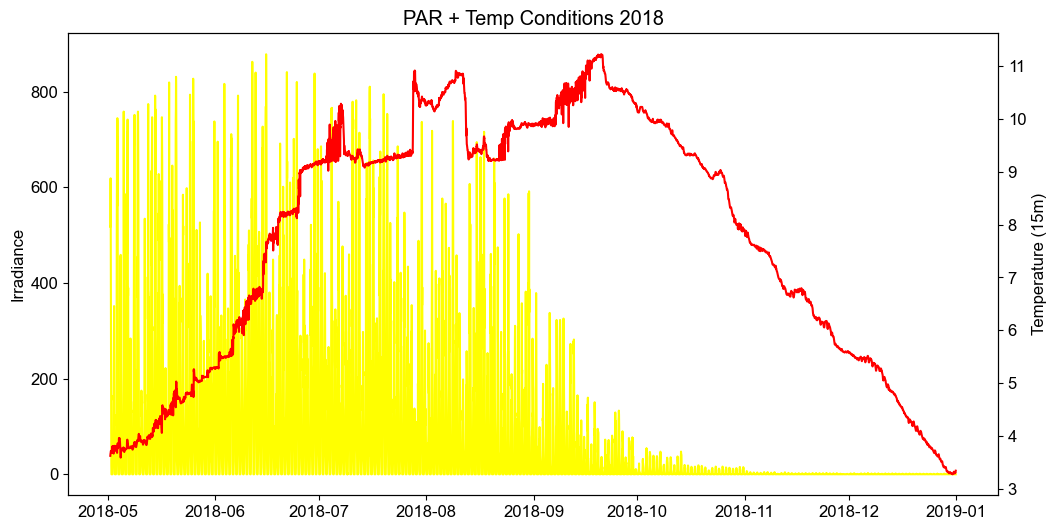

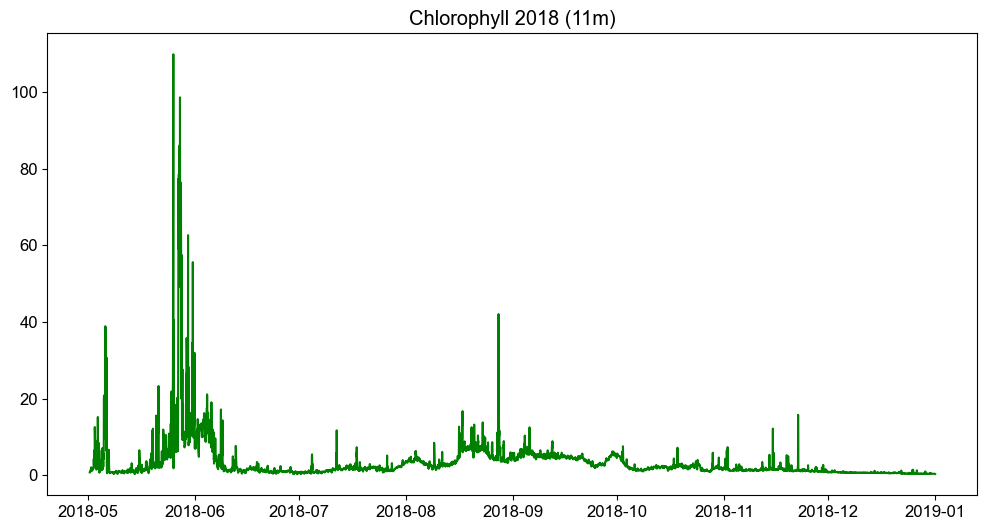

In [642]:
timestamp = M2_2018_all['time']
plt.figure(figsize=(12, 6))  # Makes figure more rectangular

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12 
plt.plot(timestamp, M2_model.y[0], color='blue') #N
plt.plot(timestamp, M2_model.y[1], color='green') #P
plt.vlines(x=timestamp[first_occurrence], ymin=0, ymax=150, colors='r', linestyles='--')
plt.ylim([0,140])
plt.title('Simplified NP model: M2 2018: Pulse on 08-01')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend(['N', 'P', 'light limitation'])
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/M2_full2018_model.jpg', dpi=300, bbox_inches='tight')

#plot environmental conditions
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(timestamp, I, color='yellow', label='Irradiance')
ax1.set_ylabel('Irradiance')
ax2 = ax1.twinx()
ax2.plot(timestamp, T, color='red', label='Temperature')
ax2.set_ylabel('Temperature (15m)')
plt.title('PAR + Temp Conditions 2018')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/PAR_temp_2018.jpg', dpi=300, bbox_inches='tight')


fig, ax3 = plt.subplots(figsize=(12, 6))
ax3.plot(timestamp, M2_2018_all[' ugrams/l'], color='green', label='Chl-a')
plt.title('Chlorophyll 2018 (11m)')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/chl_a_2018.jpg', dpi=300, bbox_inches='tight')





First negative value -0.003409384296328935 occurs at 3834
2018-10-08 21:00:00-08:00


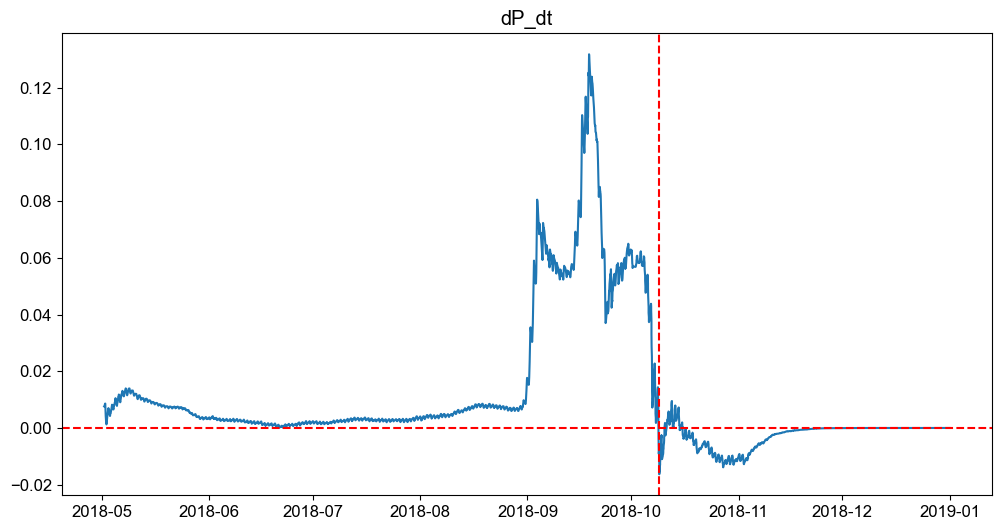

In [643]:
dP_series = pd.Series(dP_stored)
dP_smoothed = dP_series.rolling(475, min_periods=1).mean()
fig, ax4 = plt.subplots(figsize=(12, 6))
ax4.plot(timestamp, dP_smoothed)


if any(dP_smoothed < 0):  # Check if there are any negative values
    first_negative = dP_smoothed[dP_smoothed < 0].iloc[0]
    first_negative_index = dP_smoothed[dP_smoothed < 0].index[0]
    print(f"First negative value {first_negative} occurs at {first_negative_index}")
else:
    print("No negative values found")

ax4.axvline(x=timestamp[first_negative_index], color='r', linestyle='--', label='First Negative Value')
ax4.axhline(y=0, color='r', linestyle='--', label='First Negative Value')

print(timestamp[first_negative_index])
plt.title('dP_dt')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/dp_dt.jpg', dpi=300, bbox_inches='tight')


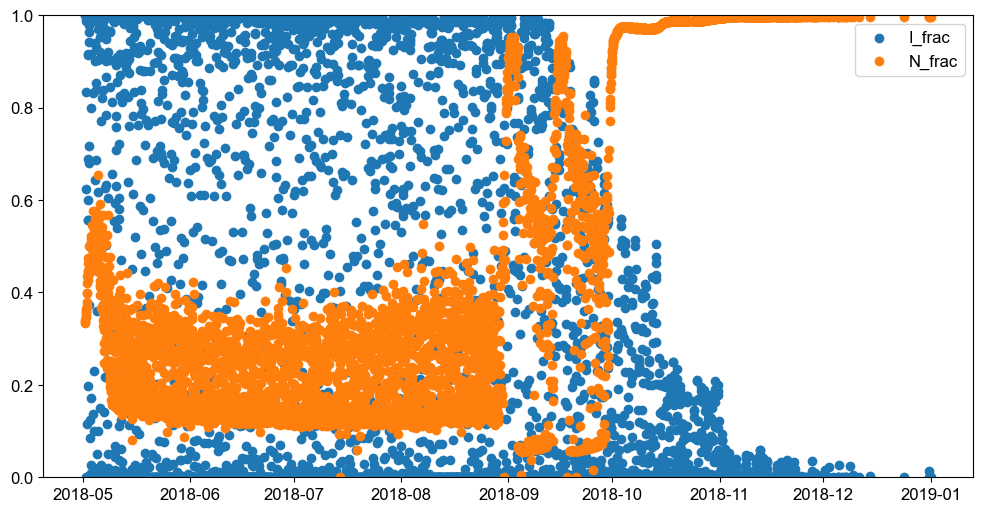

In [644]:
fig, ax4 = plt.subplots(figsize=(12, 6))
ax4.scatter(timestamp, I_frac)
ax4.scatter(timestamp, N_frac)
ax4.legend(['I_frac', 'N_frac'])
ax4.set_ylim([0,1])
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/N_frac_I_frac_timeseries.jpg', dpi=300, bbox_inches='tight')

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/3147873410.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_14800/3147873410.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  N_frac_filled = N_frac.fillna(method='bfill').to_numpy()


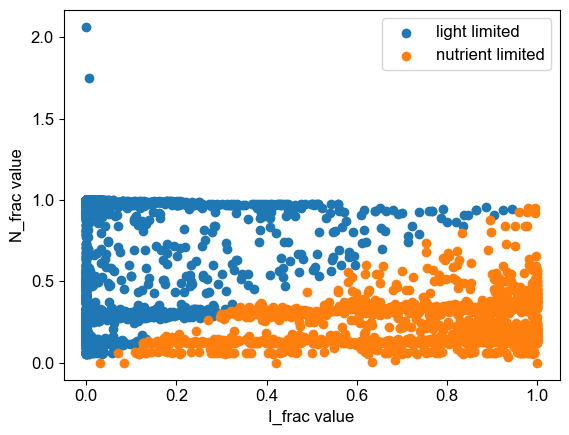

In [645]:
I_frac = pd.Series(I_frac)
N_frac = pd.Series(N_frac) #convert to series 

I_frac_filled = I_frac.fillna(method='bfill').to_numpy()
N_frac_filled = N_frac.fillna(method='bfill').to_numpy()

nut_limited = np.where(I_frac_filled > N_frac_filled)
light_limited = np.where(N_frac_filled > I_frac_filled)

nut_limited = np.array(nut_limited).squeeze()
light_limited = np.array(light_limited).squeeze()



plt.scatter(I_frac[light_limited], N_frac[light_limited])
plt.scatter(I_frac[nut_limited], N_frac[nut_limited])
plt.xlabel('I_frac value')
plt.ylabel('N_frac value')
plt.legend(['light limited', 'nutrient limited'])
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/N_frac_I_frac.jpg', dpi=300, bbox_inches='tight')

[   0    1    2 ... 3623 3625 3627]
[   8    9   10 ... 5860 5861 5862]
First 72-hour period of light limitation starts at: 2018-10-07 06:00:00-08:00


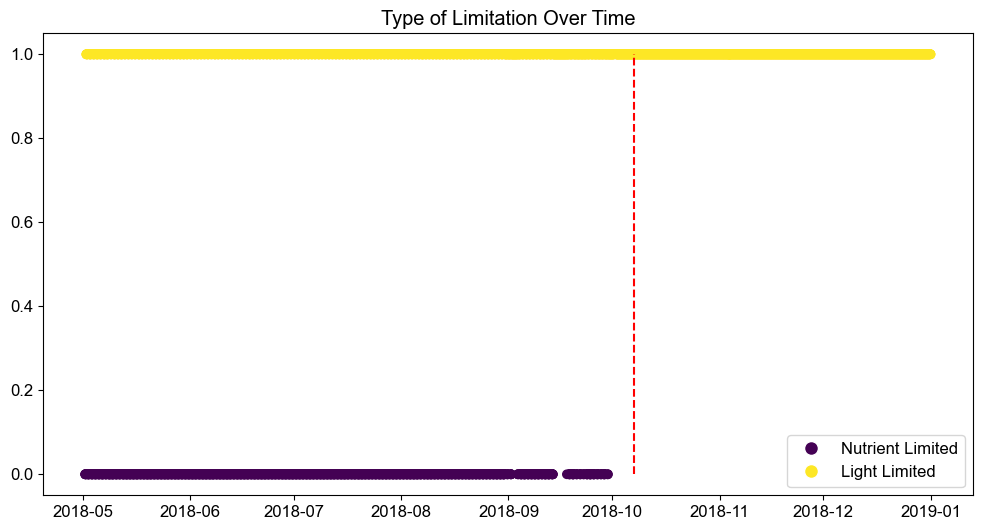

In [646]:
print(nut_limited)
print(light_limited)

limitation_terms = np.ones_like(timestamp.index)

limitation_terms[nut_limited] = 0 #1 is light limited, 0 is nutrient limited

fig, ax5= plt.subplots(figsize=(12, 6))

scatter = ax5.scatter(timestamp, limitation_terms, c=limitation_terms, cmap='viridis')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='#440154', label='Nutrient Limited', markersize=10),  # purple
                  Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='#FDE725', label='Light Limited', markersize=10)]  # yellow

# Add the legend
ax5.legend(handles=legend_elements)

#Calculate when light limitation truly begins
# Convert numpy array to pandas Series
limitation_series = pd.Series(limitation_terms)

# Now we can use rolling window: 
w = 168
consecutive_ones = limitation_series.rolling(window=w).sum()

# Find where the sum equals 72
full_day_light_limited = consecutive_ones == w

# Find first occurrence
if any(full_day_light_limited):
    first_occurrence = full_day_light_limited[full_day_light_limited].index[0]
    print(f"First 72-hour period of light limitation starts at: {timestamp[first_occurrence]}")

#plot line 

ax5.vlines(timestamp[first_occurrence], ymin=0, ymax=1, colors='r', linestyles='--')
ax5.set_title('Type of Limitation Over Time')
plt.savefig('/Users/anjalishah/Desktop/Senior_Thesis/Figures/limitation_type.jpg', dpi=300, bbox_inches='tight')

In [261]:
new_series = full_day_light_limited == True 

0       False
1       False
2       False
3       False
4       False
        ...  
5858     True
5859     True
5860     True
5861     True
5862     True
Length: 5863, dtype: bool

In [178]:
#experiment 1: constant nutrients, light limitation? --> set dn_dt = 0 always --> when does the bloom die? 

#experiment 2: abundant pulses